# 1. Exploratory Data Analysis

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

path = os.getcwd()
df = pd.read_csv( path+"//dmt_data.csv", index_col=False )

In [11]:
display( df.head() )

,DMT-Previous Experiences,Mean-PSD-pre-alpha,Mean-PSD-pre-beta,Mean-PSD-pre-delta,Mean-PSD-pre-gamma1,Mean-PSD-pre-gamma2,Mean-PSD-pre-theta,Mean-PSD-dmt-alpha,Mean-PSD-dmt-beta,Mean-PSD-dmt-delta,Mean-PSD-dmt-gamma1,Mean-PSD-dmt-gamma2,Mean-PSD-dmt-theta,Coherence-P8-Cz-beta,Coherence-P8-Pz-beta,Coherence-F7-Cz-gamma1,Coherence-F8-Pz-gamma1,Coherence-F8-POz-gamma1,Coherence-M1-CPz-gamma2,Mean-spectral-entropy
0,1,0.669,0.036,0.152,0.009,0.004,0.100,0.465,0.060,0.278,0.022,0.018,0.126,0.040,0.040,0.030,0.029,0.021,0.018,3.874
1,1,0.403,0.085,0.351,0.009,0.007,0.116,0.234,0.100,0.431,0.035,0.031,0.140,0.055,0.066,0.016,0.006,0.014,0.018,4.348
2,1,0.234,0.127,0.355,0.043,0.028,0.184,0.117,0.103,0.538,0.023,0.013,0.177,0.079,0.082,0.012,0.024,0.047,0.014,4.191
3,1,0.284,0.044,0.414,0.011,0.006,0.211,0.063,0.069,0.577,0.039,0.037,0.185,0.036,0.014,0.035,0.046,0.042,0.009,3.970
4,0,0.425,0.051,0.314,0.024,0.023,0.133,0.203,0.060,0.474,0.045,0.040,0.148,0.001,0.004,0.023,0.008,0.029,0.000,4.559


In [19]:
y = df['DMT-Previous Experiences']
X = df.drop( columns='DMT-Previous Experiences' )

# Correlations

,Mean-PSD-pre-alpha,Mean-PSD-pre-beta,Mean-PSD-pre-delta,Mean-PSD-pre-gamma1,Mean-PSD-pre-gamma2,Mean-PSD-pre-theta,Mean-PSD-dmt-alpha,Mean-PSD-dmt-beta,Mean-PSD-dmt-delta,Mean-PSD-dmt-gamma1,Mean-PSD-dmt-gamma2,Mean-PSD-dmt-theta,Coherence-P8-Cz-beta,Coherence-P8-Pz-beta,Coherence-F7-Cz-gamma1,Coherence-F8-Pz-gamma1,Coherence-F8-POz-gamma1,Coherence-M1-CPz-gamma2,Mean-spectral-entropy
Point-Biserial Correlation,0.203537,0.221899,-0.219093,-0.190525,-0.271034,-0.065712,-0.073884,0.286512,0.091009,-0.064476,-0.070584,-0.120048,0.513154,0.504135,0.252994,0.508922,0.439731,0.514933,0.115095


,Mean-PSD-pre-alpha,Mean-PSD-pre-beta,Mean-PSD-pre-delta,Mean-PSD-pre-gamma1,Mean-PSD-pre-gamma2,Mean-PSD-pre-theta,Mean-PSD-dmt-alpha,Mean-PSD-dmt-beta,Mean-PSD-dmt-delta,Mean-PSD-dmt-gamma1,Mean-PSD-dmt-gamma2,Mean-PSD-dmt-theta,Coherence-P8-Cz-beta,Coherence-P8-Pz-beta,Coherence-F7-Cz-gamma1,Coherence-F8-Pz-gamma1,Coherence-F8-POz-gamma1,Coherence-M1-CPz-gamma2,Mean-spectral-entropy
p-value,0.29888,0.256433,0.262649,0.331483,0.162997,0.739721,0.708669,0.139368,0.645103,0.744456,0.721155,0.542868,0.005229,0.00623,0.193967,0.00568,0.019208,0.005049,0.559758


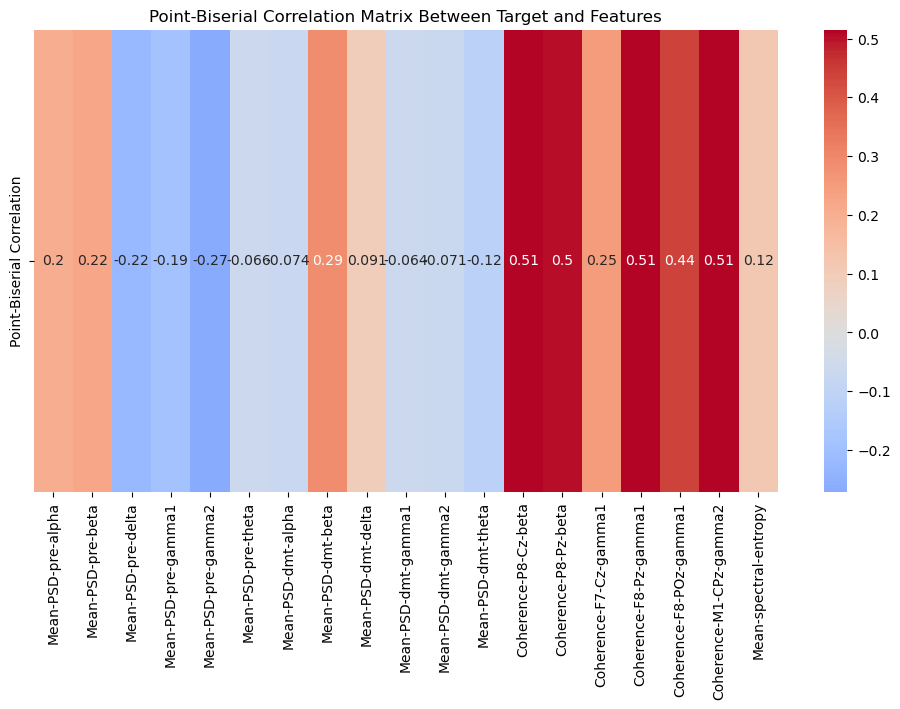

In [20]:
from scipy.stats import pointbiserialr
import seaborn as sns

correlations = {}
p_values = {}

for col in X.columns:
    corr, p_value = pointbiserialr( y, df[col] )
    correlations[col] = corr
    p_values[col] = p_value

corr = pd.DataFrame( correlations, index=['Point-Biserial Correlation'] )
corr_p_value = pd.DataFrame( p_values, index=['p-value'] )
display( corr )
display( corr_p_value )

plt.figure( figsize=(12, 6) )
sns.heatmap( corr, annot=True, cmap='coolwarm', center=0 )
plt.title( 'Point-Biserial Correlation Matrix Between Target and Features' )
plt.show()


# Logistic Regression

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split( X.values, y.values, test_size=0.2, stratify=y, random_state=42 )
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform( X_train )
X_test_scaled = scaler.transform( X_test )

logreg = LogisticRegression( solver='liblinear', max_iter=10000, random_state=42 )
logreg.fit( X_train, y_train )
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
    }

grid_search = GridSearchCV(
    estimator=logreg,
    param_grid=param_grid,
    cv=5,
    )

grid_search.fit( X_train_scaled, y_train )
best_params = grid_search.best_params_
print( f"Best parameters: {best_params}" )


Best parameters: {'C': 10, 'penalty': 'l2'}


In [27]:
best_log_reg = LogisticRegression( **best_params, random_state=42 )
best_log_reg.fit( X_train_scaled, y_train )

LogisticRegression(C=10, random_state=42)

Evaluate model performance

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

y_pred = best_log_reg.predict( X_test_scaled )
y_pred_proba = best_log_reg.predict_proba( X_test_scaled )[:, 1]
confusion = confusion_matrix( y_test, y_pred )
print( f"Confusion matrix: \n{confusion}" )
print()
print( classification_report( y_test, y_pred, target_names=['one-time', 'multiple-time'] ) )

Confusion matrix: 
[[1 1]
 [0 4]]

               precision    recall  f1-score   support

     one-time       1.00      0.50      0.67         2
multiple-time       0.80      1.00      0.89         4

     accuracy                           0.83         6
    macro avg       0.90      0.75      0.78         6
 weighted avg       0.87      0.83      0.81         6



Visualize results

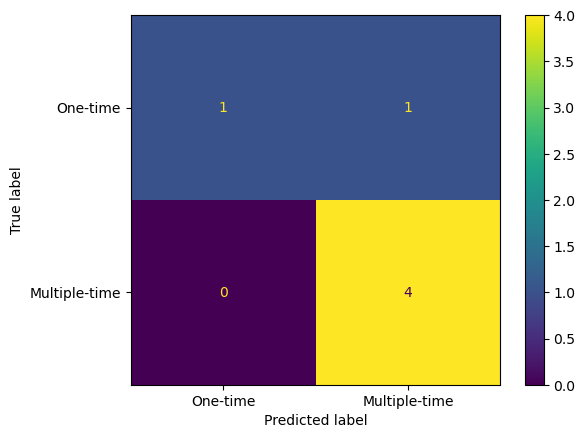

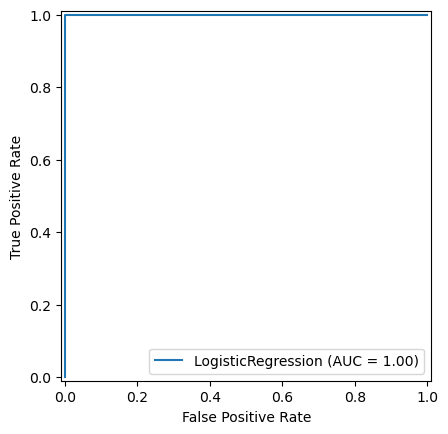

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import auc, roc_curve, RocCurveDisplay, ConfusionMatrixDisplay

confusion_disp = ConfusionMatrixDisplay( confusion_matrix=confusion, 
                                        display_labels=['One-time', 'Multiple-time'] )
confusion_disp.plot()
plt.show()

fpr, tpr, thresholds = roc_curve( y_test, y_pred_proba )
roc_auc = auc( fpr, tpr )
roc_curve = RocCurveDisplay( fpr=fpr, 
                            tpr=tpr, 
                            roc_auc=roc_auc, 
                            estimator_name='LogisticRegression' 
                            )
roc_curve.plot()
plt.show()





# Support Vector Machine(SVM)

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

